# Odor & Weather Variable Correlation Analysis

This notebook performs an advanced non-linear correlation and regression analysis between odor complaints and meteorological variables for both **Pittsburgh, PA** and **Louisville, KY** datasets.

It focuses on:
1. **Baseline-frequency-adjusted rates** to eliminate bias due to weather frequency distributions.
2. **Multivariate Poisson regression marginal effects overlays** to show the true predictive curves of the models.
3. **Advanced non-linear correlation metrics** (Spearman Rank, Mutual Information, Wald z-scores, and Drop-in-Deviance) to highlight non-linear meteorological patterns.

In [1]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries successfully imported!")

Libraries successfully imported!


## Part 1: Pittsburgh, PA Analysis

In [2]:
# Load Pittsburgh merged hourly weather and complaints data
pitt_file = 'Pittsburgh Data/open-meteo-smell-merged.csv'
print(f"Reading dataset from: {pitt_file}")
df_raw_pitt = pd.read_csv(pitt_file)

# Column mapping for Pittsburgh
column_mapping = {
    'time': 'datetime',
    'smell_report_count': 'complaints',
    'temperature_2m (°F)': 'temperature',
    'relative_humidity_2m (%)': 'relative_humidity',
    'wind_speed_10m (mp/h)': 'wind_speed',
    'wind_direction_10m (°)': 'wind_direction',
    'rain (inch)': 'precipitation',
    'dew_point_2m (°F)': 'dew_point',
    'vapour_pressure_deficit (kPa)': 'vapor_pressure',
    'surface_pressure (hPa)': 'atmospheric_pressure',
    'shortwave_radiation (W/m²)': 'solar_radiation',
    'sunshine_duration (s)': 'sunshine_duration',
    'boundary_layer_height (ft)': 'boundary_layer_height'
}
df_mapped = df_raw_pitt.rename(columns=column_mapping)
df_mapped['datetime'] = pd.to_datetime(df_mapped['datetime'])

# Aggregate hourly
df_pitt = df_mapped.groupby('datetime').agg({
    'complaints': 'sum',
    'temperature': 'mean',
    'precipitation': 'mean',
    'wind_speed': 'mean',
    'wind_direction': 'mean',
    'dew_point': 'mean',
    'relative_humidity': 'mean',
    'vapor_pressure': 'mean',
    'atmospheric_pressure': 'mean',
    'sunshine_duration': 'mean',
    'solar_radiation': 'mean',
    'boundary_layer_height': 'mean'
}).reset_index()

df_pitt['date'] = df_pitt['datetime'].dt.date
df_pitt['dayofweek'] = df_pitt['datetime'].dt.dayofweek
df_pitt['is_weekend'] = df_pitt['dayofweek'].isin([5, 6])

# Aggregate daily (using all daily complaints)
daily_df_pitt = df_pitt.groupby('date').agg({
    'complaints': 'sum',
    'is_weekend': 'first',
    'temperature': ['mean', 'min', 'max'],
    'precipitation': 'sum',
    'wind_speed': 'mean',
    'relative_humidity': 'mean',
    'atmospheric_pressure': 'mean',
    'solar_radiation': 'mean',
    'boundary_layer_height': 'mean'
}).reset_index()

daily_df_pitt.columns = [
    'date', 'complaints', 'is_weekend', 
    'temperature', 'temp_min', 'temp_max', 
    'precipitation', 'wind_speed',
    'relative_humidity', 'atmospheric_pressure', 'solar_radiation', 'boundary_layer_height'
]

daily_df_pitt['diurnal_temperature_range'] = daily_df_pitt['temp_max'] - daily_df_pitt['temp_min']
daily_df_pitt['temperature_squared'] = daily_df_pitt['temperature'] ** 2
daily_df_pitt['is_weekend'] = daily_df_pitt['is_weekend'].astype(int)

model_vars = ['temperature', 'temperature_squared', 'solar_radiation', 'relative_humidity', 
              'wind_speed', 'precipitation', 'diurnal_temperature_range', 
              'boundary_layer_height', 'atmospheric_pressure', 'is_weekend']

df_count_pitt = daily_df_pitt[['complaints'] + model_vars].dropna()
print("Pittsburgh Daily Prep Completed! Shape:", df_count_pitt.shape)

Reading dataset from: Pittsburgh Data/open-meteo-smell-merged.csv
Pittsburgh Daily Prep Completed! Shape: (3080, 11)


In [3]:
X_count_pitt = df_count_pitt[model_vars]
X_count_pitt = sm.add_constant(X_count_pitt)
y_count_pitt = df_count_pitt['complaints']

poisson_model_pitt = sm.GLM(y_count_pitt, X_count_pitt, family=sm.families.Poisson())
poisson_res_pitt = poisson_model_pitt.fit()
print("Pittsburgh Poisson Regression Results Summary:")
print(poisson_res_pitt.summary())

Pittsburgh Poisson Regression Results Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:             complaints   No. Observations:                 3080
Model:                            GLM   Df Residuals:                     3069
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -32527.
Date:                Tue, 16 Jun 2026   Deviance:                       50444.
Time:                        12:22:26   Pearson chi2:                 6.24e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

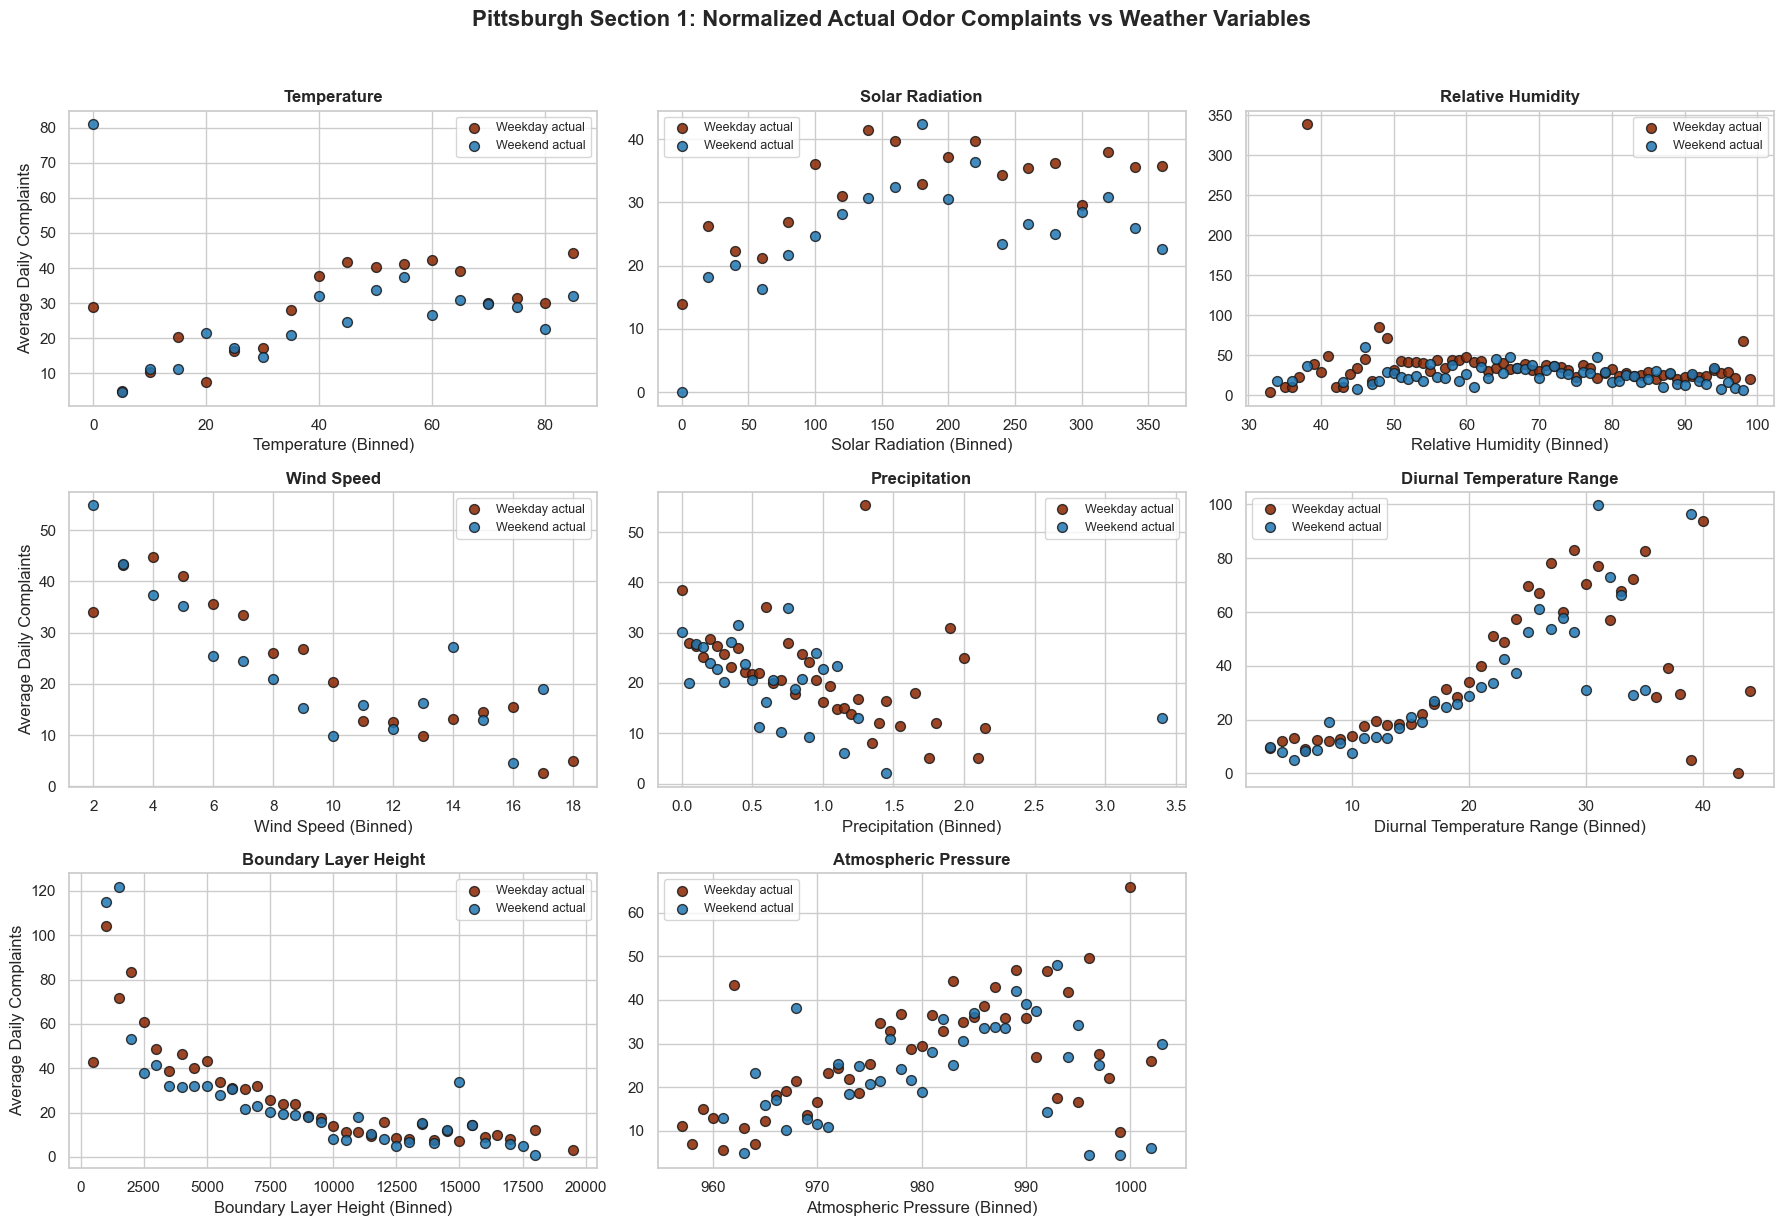

In [4]:
target_weather_vars = [
    'temperature', 
    'solar_radiation', 
    'relative_humidity', 
    'wind_speed', 
    'precipitation', 
    'diurnal_temperature_range', 
    'boundary_layer_height', 
    'atmospheric_pressure'
]

def bin_variable(series, name):
    if name == 'temperature':
        return (series / 5).round() * 5
    elif name == 'precipitation':
        return (series / 0.05).round() * 0.05
    elif name == 'wind_speed':
        return series.round()
    elif name == 'relative_humidity':
        return series.round()
    elif name == 'atmospheric_pressure':
        return series.round()
    elif name == 'solar_radiation':
        return (series / 20).round() * 20
    elif name == 'boundary_layer_height':
        return (series / 500).round() * 500
    elif name == 'diurnal_temperature_range':
        return series.round()
    return series

# Pre-calculate binned columns
for var in target_weather_vars:
    df_count_pitt[f'{var}_binned'] = bin_variable(df_count_pitt[var], var)

n_vars = len(target_weather_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

# --- SECTION 1: Normalized Actuals Only ---
fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes1 = axes1.flatten()

for i, var in enumerate(target_weather_vars):
    ax = axes1[i]
    binned_col = f'{var}_binned'
    binned_data = df_count_pitt.groupby([binned_col, 'is_weekend']).agg(
        avg_complaints=('complaints', 'mean'),
        num_days=('complaints', 'count')
    ).reset_index()
    binned_data = binned_data[binned_data['num_days'] >= 1]
    
    # Split weekdays and weekends
    wd_data = binned_data[binned_data['is_weekend'] == 0]
    we_data = binned_data[binned_data['is_weekend'] == 1]
    
    ax.scatter(wd_data[binned_col], wd_data['avg_complaints'], 
               color='#8b2500', alpha=0.85, edgecolor='k', s=50, label='Weekday actual')
    ax.scatter(we_data[binned_col], we_data['avg_complaints'], 
               color='#1f77b4', alpha=0.85, edgecolor='k', s=50, label='Weekend actual')
    
    ax.set_title(var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel(var.replace('_', ' ').title() + ' (Binned)')
    ax.set_ylabel('Average Daily Complaints' if i % n_cols == 0 else '')
    ax.legend(fontsize=9, loc='best')

for j in range(i + 1, len(axes1)):
    axes1[j].set_visible(False)

fig1.suptitle('Pittsburgh Section 1: Normalized Actual Odor Complaints vs Weather Variables', 
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

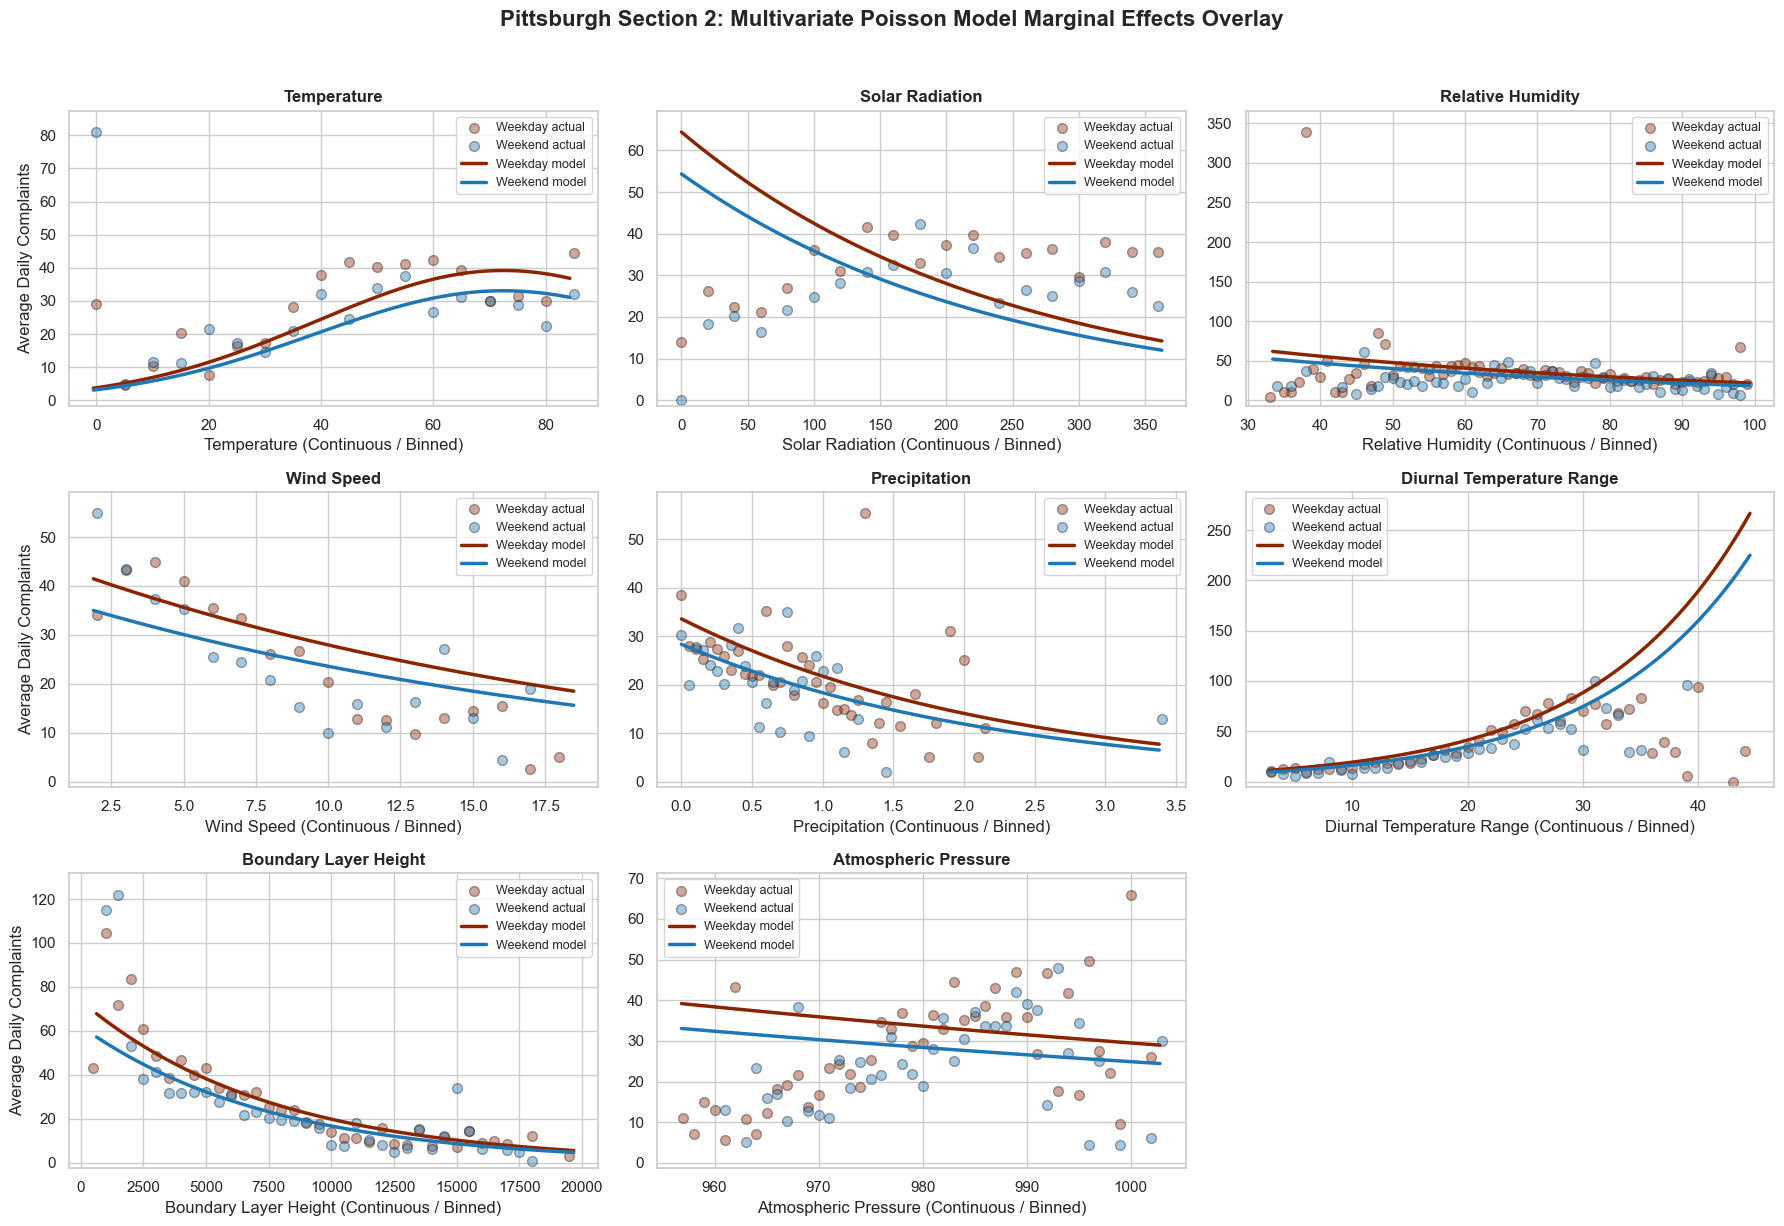

In [5]:
# --- SECTION 2: Multivariate Model Marginal Effects Overlay ---
medians_pitt = df_count_pitt[model_vars].median()

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes2 = axes2.flatten()

for i, var in enumerate(target_weather_vars):
    ax = axes2[i]
    binned_col = f'{var}_binned'
    binned_data = df_count_pitt.groupby([binned_col, 'is_weekend']).agg(
        avg_complaints=('complaints', 'mean'),
        num_days=('complaints', 'count')
    ).reset_index()
    binned_data = binned_data[binned_data['num_days'] >= 1]
    
    # Split weekdays and weekends for background
    wd_data = binned_data[binned_data['is_weekend'] == 0]
    we_data = binned_data[binned_data['is_weekend'] == 1]
    
    # Background scatter
    ax.scatter(wd_data[binned_col], wd_data['avg_complaints'], 
               color='#8b2500', alpha=0.4, edgecolor='k', s=50, label='Weekday actual')
    ax.scatter(we_data[binned_col], we_data['avg_complaints'], 
               color='#1f77b4', alpha=0.4, edgecolor='k', s=50, label='Weekend actual')
    
    # Generate smooth sequence
    var_min = df_count_pitt[var].min()
    var_max = df_count_pitt[var].max()
    var_seq = np.linspace(var_min, var_max, 200)
    
    # Weekday Prediction Line
    pred_df_wd = pd.DataFrame(index=range(200))
    pred_df_wd['const'] = 1.0
    for m_var in model_vars:
        if m_var == var:
            pred_df_wd[m_var] = var_seq
        elif var == 'temperature' and m_var == 'temperature_squared':
            pred_df_wd[m_var] = var_seq ** 2
        elif m_var == 'is_weekend':
            pred_df_wd[m_var] = 0
        else:
            pred_df_wd[m_var] = medians_pitt[m_var]
            
    pred_X_wd = pred_df_wd[['const'] + model_vars]
    pred_y_wd = poisson_res_pitt.predict(pred_X_wd)
    
    # Weekend Prediction Line
    pred_df_we = pd.DataFrame(index=range(200))
    pred_df_we['const'] = 1.0
    for m_var in model_vars:
        if m_var == var:
            pred_df_we[m_var] = var_seq
        elif var == 'temperature' and m_var == 'temperature_squared':
            pred_df_we[m_var] = var_seq ** 2
        elif m_var == 'is_weekend':
            pred_df_we[m_var] = 1
        else:
            pred_df_we[m_var] = medians_pitt[m_var]
            
    pred_X_we = pred_df_we[['const'] + model_vars]
    pred_y_we = poisson_res_pitt.predict(pred_X_we)
    
    # Overlay continuous prediction lines
    ax.plot(var_seq, pred_y_wd, color='#8b2500', linewidth=2.5, label='Weekday model')
    ax.plot(var_seq, pred_y_we, color='#1f77b4', linewidth=2.5, label='Weekend model')
    
    # Align Y-axis scales
    max_actual_wd = wd_data['avg_complaints'].max() if not wd_data.empty else 0
    max_actual_we = we_data['avg_complaints'].max() if not we_data.empty else 0
    max_y = max(max_actual_wd, max_actual_we, pred_y_wd.max(), pred_y_we.max())
    ax.set_ylim(-0.02 * max_y, max_y * 1.08)
    
    ax.set_title(var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel(var.replace('_', ' ').title() + ' (Continuous / Binned)')
    ax.set_ylabel('Average Daily Complaints' if i % n_cols == 0 else '')
    ax.legend(fontsize=9, loc='best')

for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

fig2.suptitle('Pittsburgh Section 2: Multivariate Poisson Model Marginal Effects Overlay', 
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# --- SECTION 2: Advanced Non-Linear Correlation Metrics ---
print("Calculating advanced correlation metrics for Pittsburgh...")

# 1. Pearson and Spearman correlations
pearson_pitt = {}
spearman_pitt = {}
for var in target_weather_vars:
    r_val, _ = pearsonr(df_count_pitt['complaints'], df_count_pitt[var])
    rho_val, _ = spearmanr(df_count_pitt['complaints'], df_count_pitt[var])
    pearson_pitt[var] = r_val
    spearman_pitt[var] = rho_val

# 2. Mutual Information (MI)
X_mi_pitt = df_count_pitt[target_weather_vars]
y_mi_pitt = df_count_pitt['complaints']
mi_scores_pitt = mutual_info_regression(X_mi_pitt, y_mi_pitt, random_state=42)
mi_pitt = dict(zip(target_weather_vars, mi_scores_pitt))

# 3. Model z-scores and Drop-in-Deviance
tvalues_pitt = poisson_res_pitt.tvalues
z_pitt = {}
dev_pitt = {}
full_dev_pitt = poisson_res_pitt.deviance

for var in target_weather_vars:
    if var == 'temperature':
        z_pitt[var] = max(abs(tvalues_pitt['temperature']), abs(tvalues_pitt['temperature_squared']))
        vars_keep = [v for v in model_vars if v != 'temperature' and v != 'temperature_squared']
    else:
        z_pitt[var] = abs(tvalues_pitt[var])
        vars_keep = [v for v in model_vars if v != var]
        
    X_red = sm.add_constant(df_count_pitt[vars_keep])
    red_model = sm.GLM(y_count_pitt, X_red, family=sm.families.Poisson())
    red_res = red_model.fit()
    dev_pitt[var] = red_res.deviance - full_dev_pitt

print("Pittsburgh metrics successfully computed!")

Calculating advanced correlation metrics for Pittsburgh...
Pittsburgh metrics successfully computed!


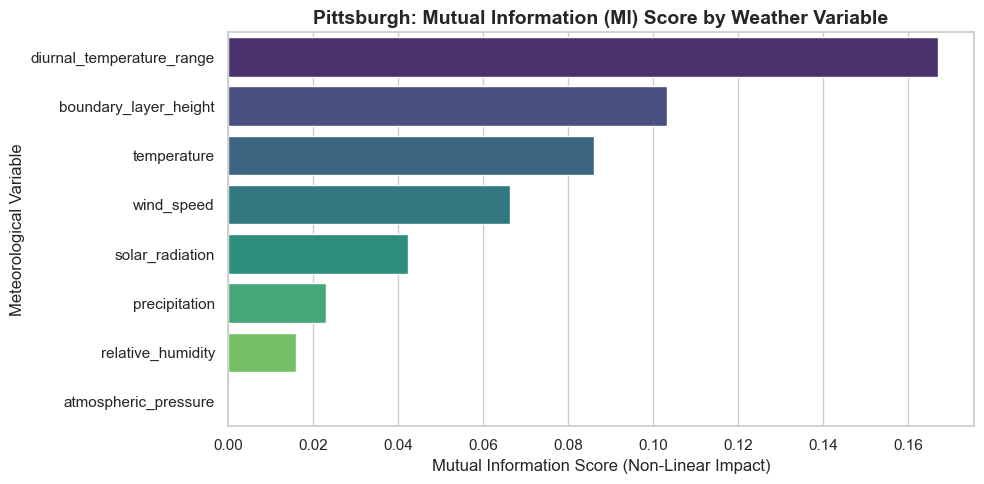

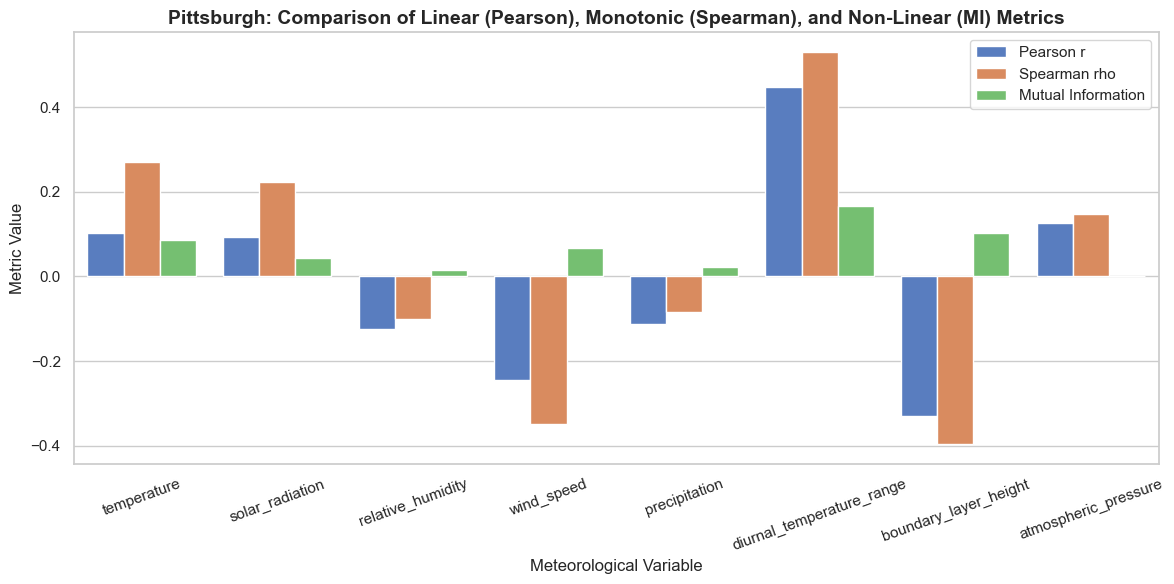

Pittsburgh Correlation Metrics Summary Table:


,Variable,Pearson r,Spearman rho,Mutual Information,Wald z-score,Drop-in-Deviance
0,temperature,0.102,0.271,0.086,48.09,5801.5
1,solar_radiation,0.092,0.222,0.042,53.87,2952.8
2,relative_humidity,-0.123,-0.100,0.016,36.21,1286.5
3,wind_speed,-0.245,-0.349,0.066,20.74,431.1
4,precipitation,-0.112,-0.084,0.023,22.93,566.4
5,diurnal_temperature_range,0.448,0.530,0.167,119.63,13130.8
6,boundary_layer_height,-0.329,-0.397,0.103,58.31,3539.2
7,atmospheric_pressure,0.127,0.146,0.000,9.44,89.0


In [7]:
# --- SECTION 3: Correlation Metrics Visualization ---
pitt_comp = pd.DataFrame({
    'Variable': target_weather_vars,
    'Pearson r': [pearson_pitt[v] for v in target_weather_vars],
    'Spearman rho': [spearman_pitt[v] for v in target_weather_vars],
    'Mutual Information': [mi_pitt[v] for v in target_weather_vars],
    'Wald z-score': [z_pitt[v] for v in target_weather_vars],
    'Drop-in-Deviance': [dev_pitt[v] for v in target_weather_vars]
})

# Horizontal bar chart of Mutual Information (MI)
mi_sorted = pitt_comp.sort_values(by='Mutual Information', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='Mutual Information', y='Variable', data=mi_sorted, palette='viridis', hue='Variable', legend=False)
plt.title('Pittsburgh: Mutual Information (MI) Score by Weather Variable', fontsize=14, fontweight='bold')
plt.xlabel('Mutual Information Score (Non-Linear Impact)')
plt.ylabel('Meteorological Variable')
plt.tight_layout()
plt.show()

# Melt for comparison of Pearson, Spearman, and MI
melted_pitt = pitt_comp.melt(id_vars='Variable', value_vars=['Pearson r', 'Spearman rho', 'Mutual Information'],
                             var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 6))
sns.barplot(x='Variable', y='Value', hue='Metric', data=melted_pitt, palette='muted')
plt.title('Pittsburgh: Comparison of Linear (Pearson), Monotonic (Spearman), and Non-Linear (MI) Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Meteorological Variable')
plt.ylabel('Metric Value')
plt.xticks(rotation=20)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print("Pittsburgh Correlation Metrics Summary Table:")
pitt_comp.style.background_gradient(cmap='coolwarm', subset=['Pearson r', 'Spearman rho'])\
              .background_gradient(cmap='viridis', subset=['Mutual Information', 'Wald z-score', 'Drop-in-Deviance'])\
              .format({
                  'Pearson r': '{:.3f}',
                  'Spearman rho': '{:.3f}',
                  'Mutual Information': '{:.3f}',
                  'Wald z-score': '{:.2f}',
                  'Drop-in-Deviance': '{:.1f}'
              })

## Part 2: Louisville, KY Analysis

In [8]:
# Load Louisville merged hourly weather and complaints data
lville_file = 'Louisville Data/open-meteo-smell-merged.csv'
print(f"Reading dataset from: {lville_file}")
df_raw_lville = pd.read_csv(lville_file)

# Column mapping for Louisville
df_mapped_l = df_raw_lville.rename(columns=column_mapping)
df_mapped_l['datetime'] = pd.to_datetime(df_mapped_l['datetime'])

# Aggregate hourly
df_lville = df_mapped_l.groupby('datetime').agg({
    'complaints': 'sum',
    'temperature': 'mean',
    'precipitation': 'mean',
    'wind_speed': 'mean',
    'wind_direction': 'mean',
    'dew_point': 'mean',
    'relative_humidity': 'mean',
    'vapor_pressure': 'mean',
    'atmospheric_pressure': 'mean',
    'sunshine_duration': 'mean',
    'solar_radiation': 'mean',
    'boundary_layer_height': 'mean'
}).reset_index()

df_lville['date'] = df_lville['datetime'].dt.date
df_lville['dayofweek'] = df_lville['datetime'].dt.dayofweek
df_lville['is_weekend'] = df_lville['dayofweek'].isin([5, 6])

# Aggregate daily (using all daily complaints)
daily_df_lville = df_lville.groupby('date').agg({
    'complaints': 'sum',
    'is_weekend': 'first',
    'temperature': ['mean', 'min', 'max'],
    'precipitation': 'sum',
    'wind_speed': 'mean',
    'relative_humidity': 'mean',
    'atmospheric_pressure': 'mean',
    'solar_radiation': 'mean',
    'boundary_layer_height': 'mean'
}).reset_index()

daily_df_lville.columns = [
    'date', 'complaints', 'is_weekend', 
    'temperature', 'temp_min', 'temp_max', 
    'precipitation', 'wind_speed',
    'relative_humidity', 'atmospheric_pressure', 'solar_radiation', 'boundary_layer_height'
]

daily_df_lville['diurnal_temperature_range'] = daily_df_lville['temp_max'] - daily_df_lville['temp_min']
daily_df_lville['temperature_squared'] = daily_df_lville['temperature'] ** 2
daily_df_lville['is_weekend'] = daily_df_lville['is_weekend'].astype(int)

df_count_lville = daily_df_lville[['complaints'] + model_vars].dropna()
print("Louisville Daily Prep Completed! Shape:", df_count_lville.shape)

Reading dataset from: Louisville Data/open-meteo-smell-merged.csv
Louisville Daily Prep Completed! Shape: (3080, 11)


In [9]:
X_count_lville = df_count_lville[model_vars]
X_count_lville = sm.add_constant(X_count_lville)
y_count_lville = df_count_lville['complaints']

poisson_model_lville = sm.GLM(y_count_lville, X_count_lville, family=sm.families.Poisson())
poisson_res_lville = poisson_model_lville.fit()
print("Louisville Poisson Regression Results Summary:")
print(poisson_res_lville.summary())

Louisville Poisson Regression Results Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:             complaints   No. Observations:                 3080
Model:                            GLM   Df Residuals:                     3069
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10381.
Date:                Tue, 16 Jun 2026   Deviance:                       14316.
Time:                        12:22:33   Pearson chi2:                 2.11e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.7413
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

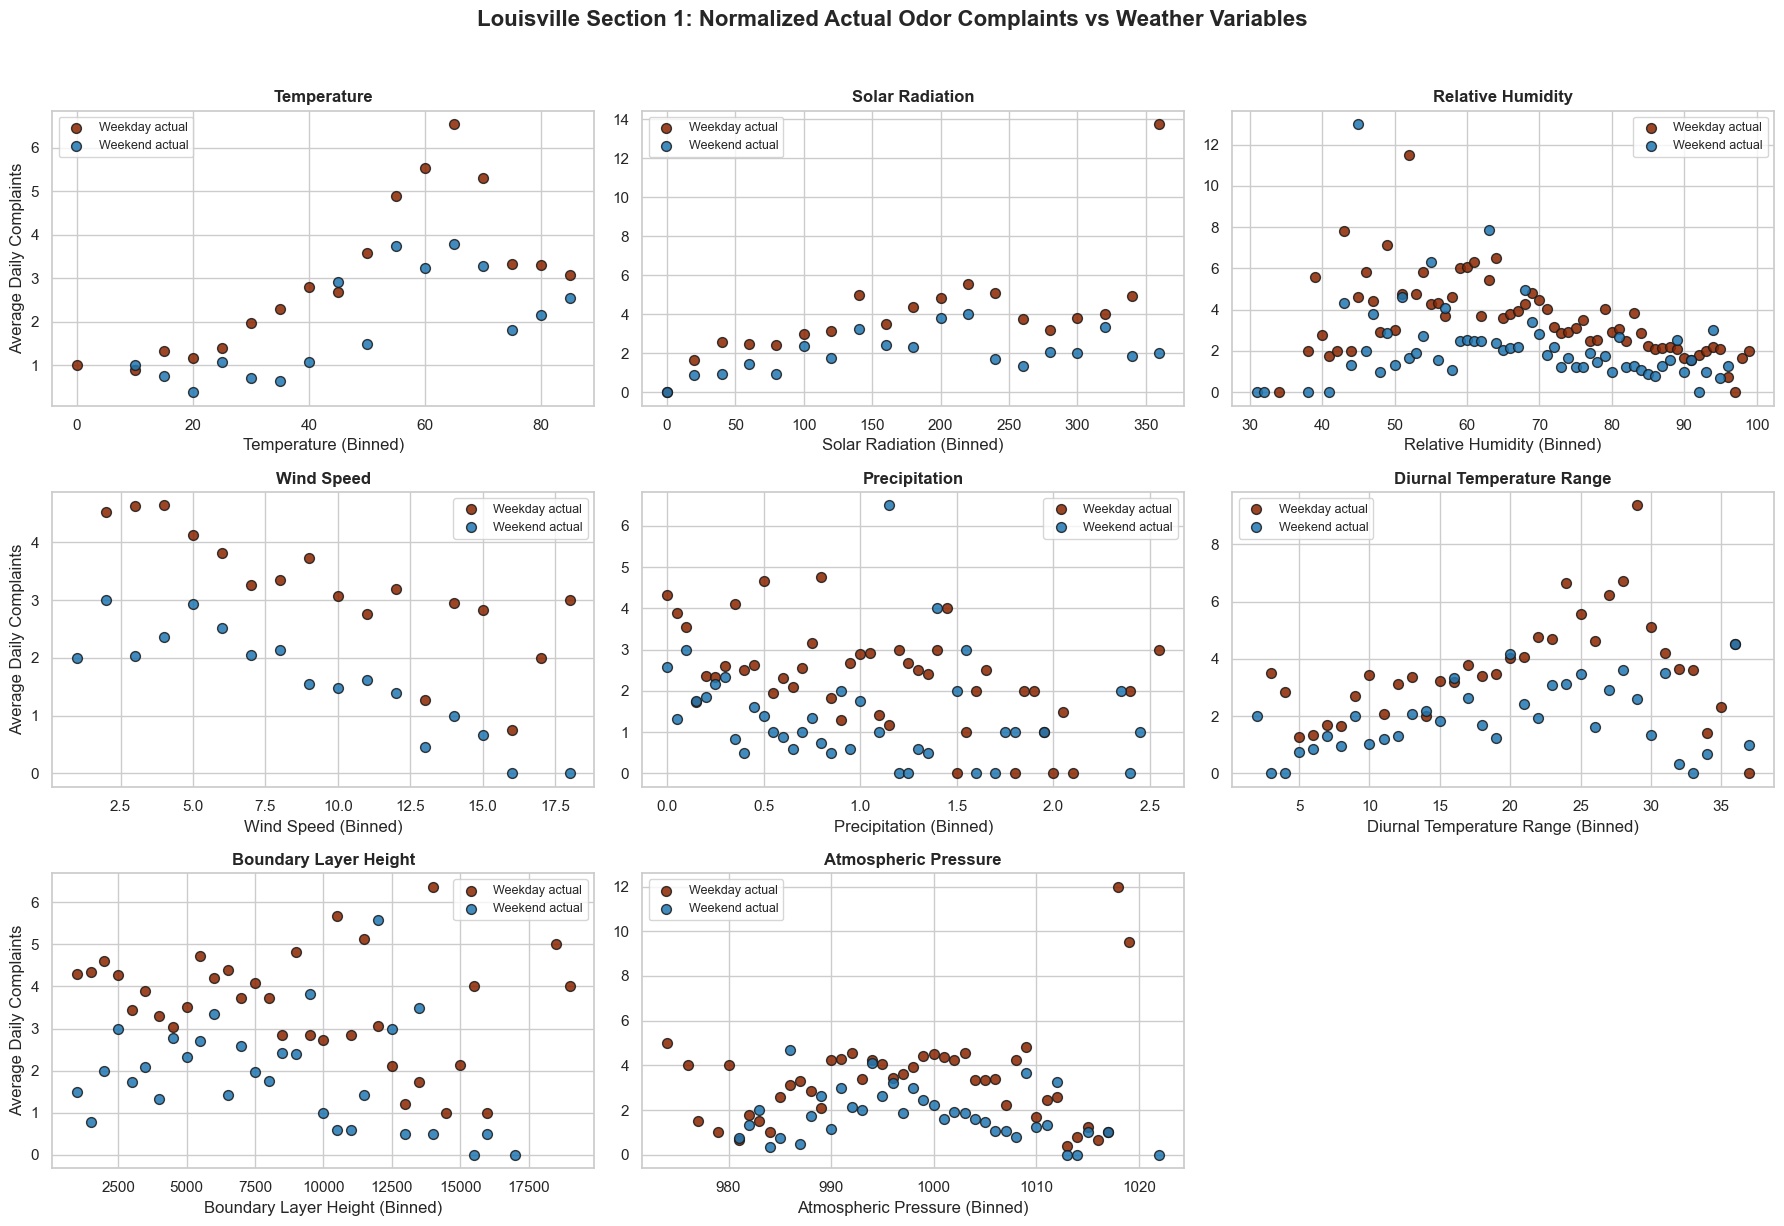

In [10]:
# Pre-calculate binned columns for Louisville
for var in target_weather_vars:
    df_count_lville[f'{var}_binned'] = bin_variable(df_count_lville[var], var)

# --- SECTION 1: Normalized Actuals Only ---
fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes3 = axes3.flatten()

for i, var in enumerate(target_weather_vars):
    ax = axes3[i]
    binned_col = f'{var}_binned'
    binned_data = df_count_lville.groupby([binned_col, 'is_weekend']).agg(
        avg_complaints=('complaints', 'mean'),
        num_days=('complaints', 'count')
    ).reset_index()
    binned_data = binned_data[binned_data['num_days'] >= 1]
    
    # Split weekdays and weekends
    wd_data = binned_data[binned_data['is_weekend'] == 0]
    we_data = binned_data[binned_data['is_weekend'] == 1]
    
    ax.scatter(wd_data[binned_col], wd_data['avg_complaints'], 
               color='#8b2500', alpha=0.85, edgecolor='k', s=50, label='Weekday actual')
    ax.scatter(we_data[binned_col], we_data['avg_complaints'], 
               color='#1f77b4', alpha=0.85, edgecolor='k', s=50, label='Weekend actual')
    
    ax.set_title(var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel(var.replace('_', ' ').title() + ' (Binned)')
    ax.set_ylabel('Average Daily Complaints' if i % n_cols == 0 else '')
    ax.legend(fontsize=9, loc='best')

for j in range(i + 1, len(axes3)):
    axes3[j].set_visible(False)

fig3.suptitle('Louisville Section 1: Normalized Actual Odor Complaints vs Weather Variables', 
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

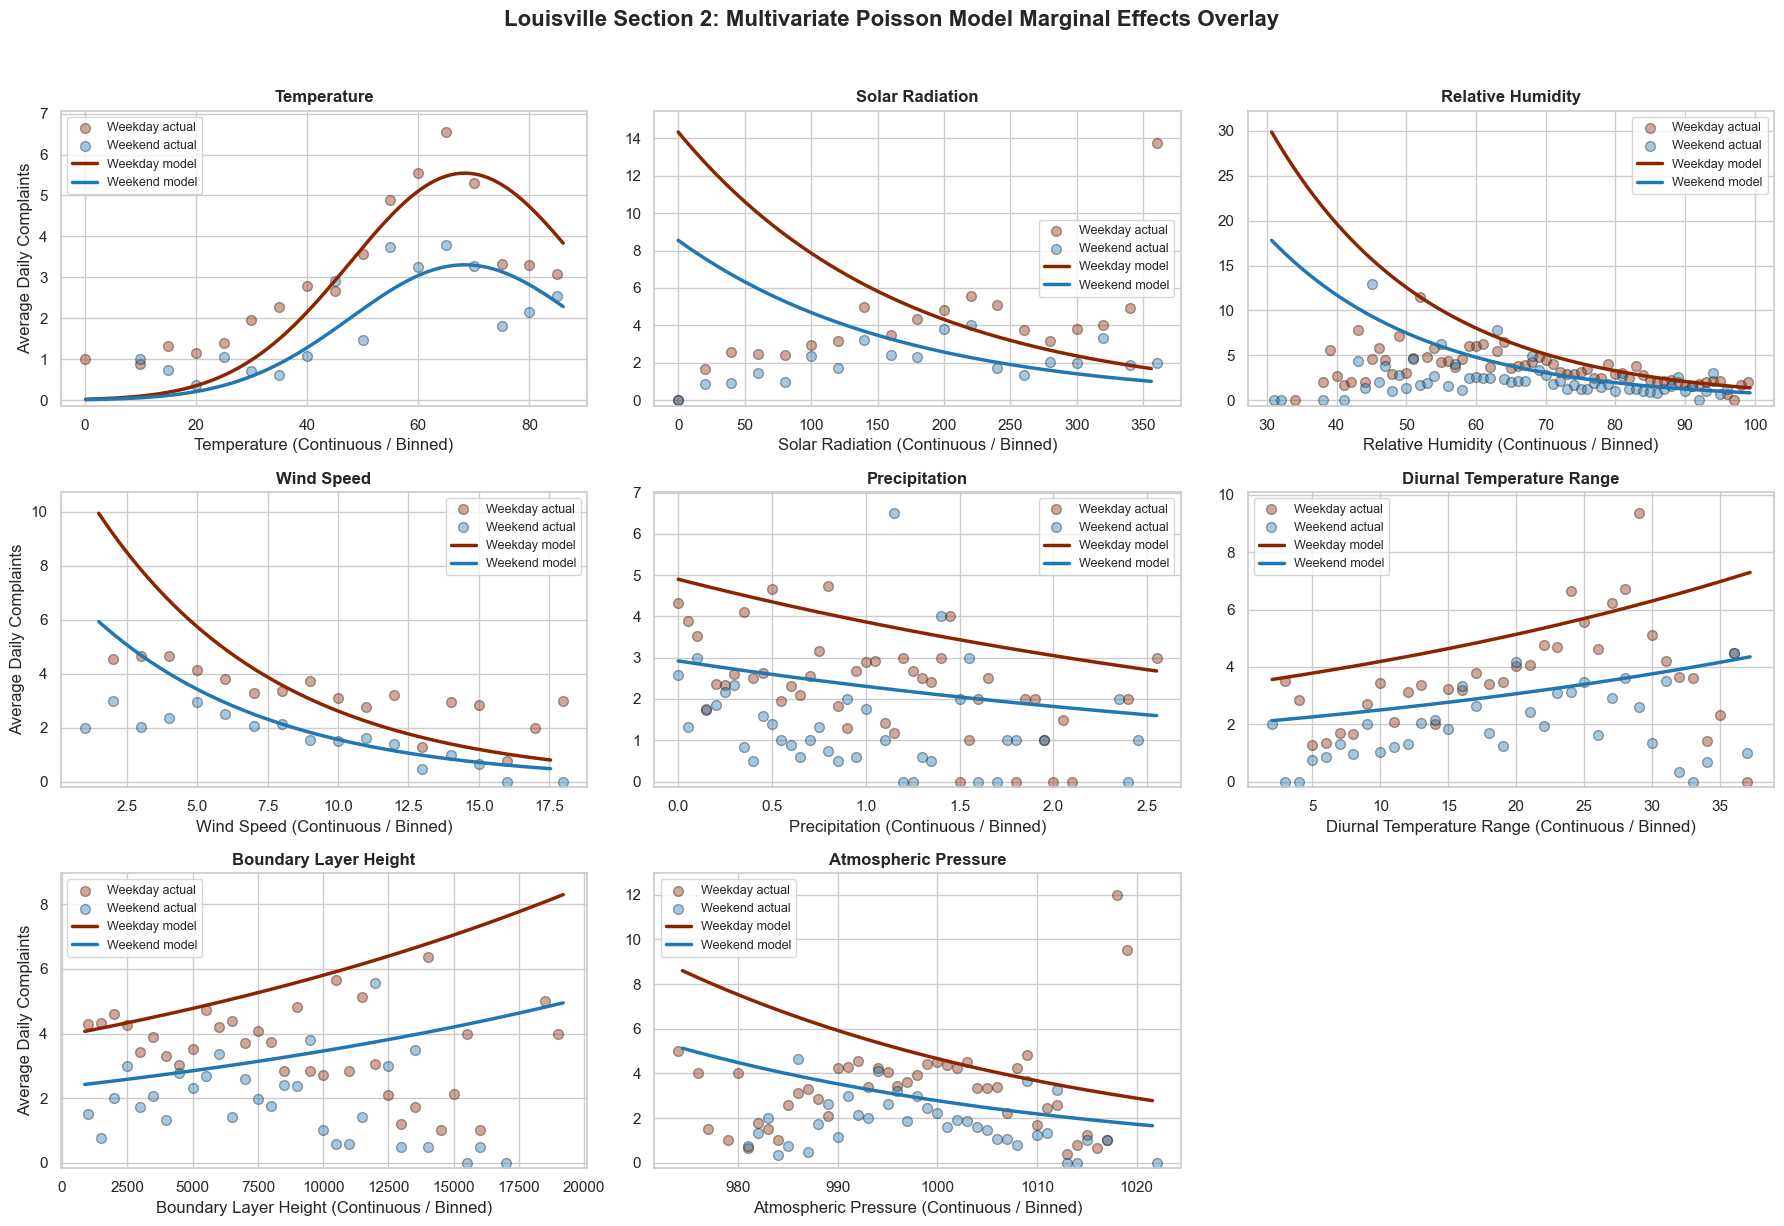

In [11]:
# --- SECTION 2: Multivariate Model Marginal Effects Overlay ---
medians_lville = df_count_lville[model_vars].median()

fig4, axes4 = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes4 = axes4.flatten()

for i, var in enumerate(target_weather_vars):
    ax = axes4[i]
    binned_col = f'{var}_binned'
    binned_data = df_count_lville.groupby([binned_col, 'is_weekend']).agg(
        avg_complaints=('complaints', 'mean'),
        num_days=('complaints', 'count')
    ).reset_index()
    binned_data = binned_data[binned_data['num_days'] >= 1]
    
    # Split weekdays and weekends for background
    wd_data = binned_data[binned_data['is_weekend'] == 0]
    we_data = binned_data[binned_data['is_weekend'] == 1]
    
    # Background scatter
    ax.scatter(wd_data[binned_col], wd_data['avg_complaints'], 
               color='#8b2500', alpha=0.4, edgecolor='k', s=50, label='Weekday actual')
    ax.scatter(we_data[binned_col], we_data['avg_complaints'], 
               color='#1f77b4', alpha=0.4, edgecolor='k', s=50, label='Weekend actual')
    
    # Generate smooth sequence
    var_min = df_count_lville[var].min()
    var_max = df_count_lville[var].max()
    var_seq = np.linspace(var_min, var_max, 200)
    
    # Weekday Prediction Line
    pred_df_wd = pd.DataFrame(index=range(200))
    pred_df_wd['const'] = 1.0
    for m_var in model_vars:
        if m_var == var:
            pred_df_wd[m_var] = var_seq
        elif var == 'temperature' and m_var == 'temperature_squared':
            pred_df_wd[m_var] = var_seq ** 2
        elif m_var == 'is_weekend':
            pred_df_wd[m_var] = 0
        else:
            pred_df_wd[m_var] = medians_lville[m_var]
            
    pred_X_wd = pred_df_wd[['const'] + model_vars]
    pred_y_wd = poisson_res_lville.predict(pred_X_wd)
    
    # Weekend Prediction Line
    pred_df_we = pd.DataFrame(index=range(200))
    pred_df_we['const'] = 1.0
    for m_var in model_vars:
        if m_var == var:
            pred_df_we[m_var] = var_seq
        elif var == 'temperature' and m_var == 'temperature_squared':
            pred_df_we[m_var] = var_seq ** 2
        elif m_var == 'is_weekend':
            pred_df_we[m_var] = 1
        else:
            pred_df_we[m_var] = medians_lville[m_var]
            
    pred_X_we = pred_df_we[['const'] + model_vars]
    pred_y_we = poisson_res_lville.predict(pred_X_we)
    
    # Overlay continuous prediction lines
    ax.plot(var_seq, pred_y_wd, color='#8b2500', linewidth=2.5, label='Weekday model')
    ax.plot(var_seq, pred_y_we, color='#1f77b4', linewidth=2.5, label='Weekend model')
    
    # Align Y-axis scales
    max_actual_wd = wd_data['avg_complaints'].max() if not wd_data.empty else 0
    max_actual_we = we_data['avg_complaints'].max() if not we_data.empty else 0
    max_y = max(max_actual_wd, max_actual_we, pred_y_wd.max(), pred_y_we.max())
    ax.set_ylim(-0.02 * max_y, max_y * 1.08)
    
    ax.set_title(var.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel(var.replace('_', ' ').title() + ' (Continuous / Binned)')
    ax.set_ylabel('Average Daily Complaints' if i % n_cols == 0 else '')
    ax.legend(fontsize=9, loc='best')

for j in range(i + 1, len(axes4)):
    axes4[j].set_visible(False)

fig4.suptitle('Louisville Section 2: Multivariate Poisson Model Marginal Effects Overlay', 
              fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# --- SECTION 2: Advanced Non-Linear Correlation Metrics ---
print("Calculating advanced correlation metrics for Louisville...")

# 1. Pearson and Spearman correlations
pearson_lville = {}
spearman_lville = {}
for var in target_weather_vars:
    r_val, _ = pearsonr(df_count_lville['complaints'], df_count_lville[var])
    rho_val, _ = spearmanr(df_count_lville['complaints'], df_count_lville[var])
    pearson_lville[var] = r_val
    spearman_lville[var] = rho_val

# 2. Mutual Information (MI)
X_mi_lville = df_count_lville[target_weather_vars]
y_mi_lville = df_count_lville['complaints']
mi_scores_lville = mutual_info_regression(X_mi_lville, y_mi_lville, random_state=42)
mi_lville = dict(zip(target_weather_vars, mi_scores_lville))

# 3. Model z-scores and Drop-in-Deviance
tvalues_lville = poisson_res_lville.tvalues
z_lville = {}
dev_lville = {}
full_dev_lville = poisson_res_lville.deviance

for var in target_weather_vars:
    if var == 'temperature':
        z_lville[var] = max(abs(tvalues_lville['temperature']), abs(tvalues_lville['temperature_squared']))
        vars_keep = [v for v in model_vars if v != 'temperature' and v != 'temperature_squared']
    else:
        z_lville[var] = abs(tvalues_lville[var])
        vars_keep = [v for v in model_vars if v != var]
        
    X_red = sm.add_constant(df_count_lville[vars_keep])
    red_model = sm.GLM(y_count_lville, X_red, family=sm.families.Poisson())
    red_res = red_model.fit()
    dev_lville[var] = red_res.deviance - full_dev_lville

print("Louisville metrics successfully computed!")

Calculating advanced correlation metrics for Louisville...
Louisville metrics successfully computed!


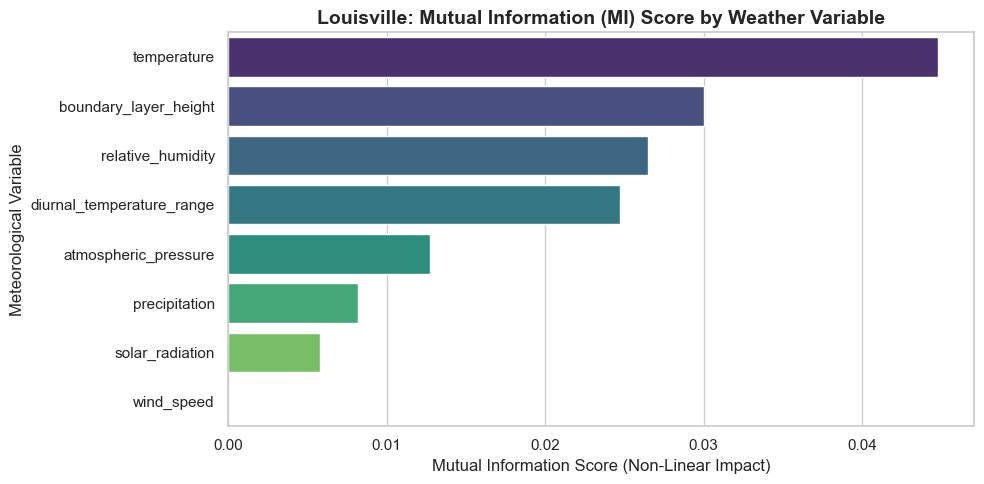

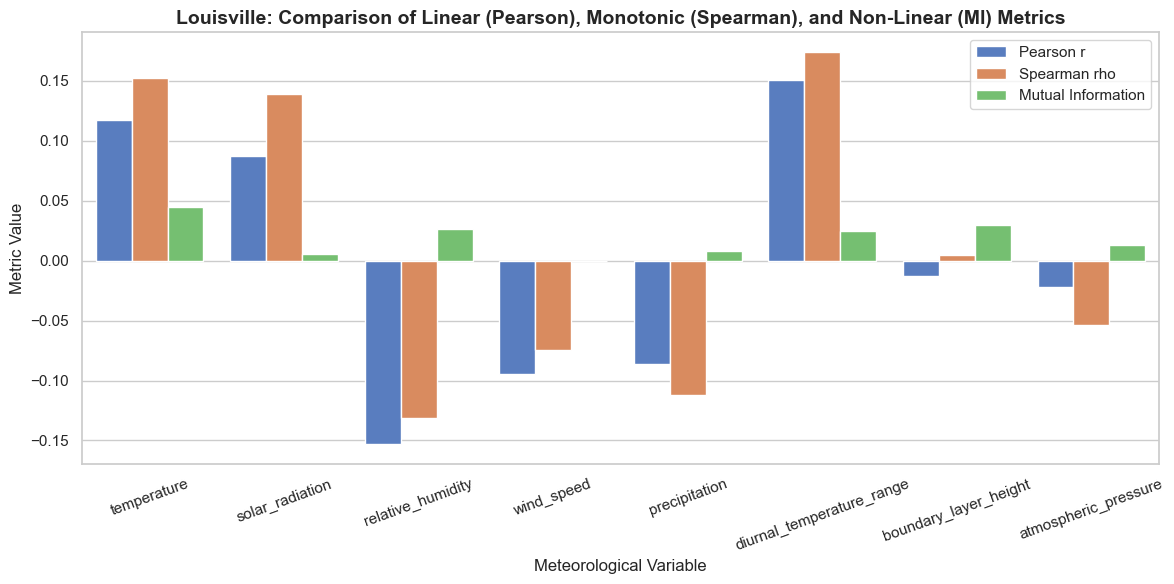

Louisville Correlation Metrics Summary Table:


,Variable,Pearson r,Spearman rho,Mutual Information,Wald z-score,Drop-in-Deviance
0,temperature,0.117,0.153,0.045,28.17,1545.9
1,solar_radiation,0.088,0.139,0.006,27.14,749.1
2,relative_humidity,-0.153,-0.131,0.026,34.60,1144.5
3,wind_speed,-0.094,-0.074,0.000,24.67,618.8
4,precipitation,-0.086,-0.112,0.008,4.63,22.6
5,diurnal_temperature_range,0.150,0.174,0.025,9.34,86.2
6,boundary_layer_height,-0.013,0.005,0.030,6.13,37.3
7,atmospheric_pressure,-0.022,-0.053,0.013,10.22,104.1


In [13]:
# --- SECTION 3: Correlation Metrics Visualization ---
lville_comp = pd.DataFrame({
    'Variable': target_weather_vars,
    'Pearson r': [pearson_lville[v] for v in target_weather_vars],
    'Spearman rho': [spearman_lville[v] for v in target_weather_vars],
    'Mutual Information': [mi_lville[v] for v in target_weather_vars],
    'Wald z-score': [z_lville[v] for v in target_weather_vars],
    'Drop-in-Deviance': [dev_lville[v] for v in target_weather_vars]
})

# Horizontal bar chart of Mutual Information (MI)
mi_sorted_l = lville_comp.sort_values(by='Mutual Information', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='Mutual Information', y='Variable', data=mi_sorted_l, palette='viridis', hue='Variable', legend=False)
plt.title('Louisville: Mutual Information (MI) Score by Weather Variable', fontsize=14, fontweight='bold')
plt.xlabel('Mutual Information Score (Non-Linear Impact)')
plt.ylabel('Meteorological Variable')
plt.tight_layout()
plt.show()

# Melt for comparison of Pearson, Spearman, and MI
melted_lville = lville_comp.melt(id_vars='Variable', value_vars=['Pearson r', 'Spearman rho', 'Mutual Information'],
                             var_name='Metric', value_name='Value')
plt.figure(figsize=(12, 6))
sns.barplot(x='Variable', y='Value', hue='Metric', data=melted_lville, palette='muted')
plt.title('Louisville: Comparison of Linear (Pearson), Monotonic (Spearman), and Non-Linear (MI) Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Meteorological Variable')
plt.ylabel('Metric Value')
plt.xticks(rotation=20)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print("Louisville Correlation Metrics Summary Table:")
lville_comp.style.background_gradient(cmap='coolwarm', subset=['Pearson r', 'Spearman rho'])\
                .background_gradient(cmap='viridis', subset=['Mutual Information', 'Wald z-score', 'Drop-in-Deviance'])\
                .format({
                    'Pearson r': '{:.3f}',
                    'Spearman rho': '{:.3f}',
                    'Mutual Information': '{:.3f}',
                    'Wald z-score': '{:.2f}',
                    'Drop-in-Deviance': '{:.1f}'
                })